# DPS – Z‑transformacija

Ta zvezek sledi strukturi predavanj: **definicije, lastnosti, dokazi, primeri** in za izbrane sklope
vključuje *izvajalne* Python/SymPy/Numpy/SciPy primere in vizualizacije.

**Cilj:** utrditi razumevanje Z‑transformacije, ROC, lastnosti, prenosne funkcije, inverzne Z‑transformacije,
polov/ničel, stabilnosti in realizacijskih struktur (DF1, DF2, kaskadna, paralelna).

In [1]:
# Uvoz knjižnic
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib import colors as mcolors
from scipy import signal
import sympy as sp

plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.figsize'] = (7,6)

## 1) Definicija Z‑transformacije

Za zaporedje $x[n]$ definiramo
$${X(z) = \sum_{n=-\infty}^{\infty} x[n] z^{-n}}, \quad z\in\mathbb{C}. $$

Za **kavzalna** zaporedja (neničelna za $n\ge 0$):
$${X(z) = \sum_{n=0}^{\infty} x[n] z^{-n}}.$$

Kadar velja  $z=e^{j\omega}$ (točka na enotski krožnici), povezujemo Z‑transform z DTFT.

### Primeri osnovnih signalov in njihove Z-transformacije

V nadaljevanju bomo izračunali Z-transformacijo treh osnovnih diskretnih signalov, ki pogosto nastopajo pri analizi digitalnih sistemov.
Ti signali predstavljajo osnovne gradnike in omogočajo jasno razumevanje delovanja Z-transformacije ter regije konvergence (ROC).

Signali, ki jih bomo obravnavali:

- enotin impulz $ \delta[n] $
- enotina stopnica $ u[n] $
- geometrijsko zaporedje $ a^n u[n] $

Za vsak signal bomo določili njegovo Z-transformacijo $ X(z) $, preverili pogoje konvergence (ROC) ter opazovali, kako SymPy rezultate prikaže v obliki racionalnih funkcij ali struktur.

Ti primeri služijo kot izhodišče za razumevanje racionalnih Z-transformov, polov, ničel ter kasnejših poglavij o stabilnosti in realizaciji diskretnih sistemov.

In [2]:
import sympy as sp
from sympy import Eq, Symbol
from IPython.display import display

n = sp.symbols('n', integer=True)
z = sp.symbols('z', complex=True)
a = sp.symbols('a', complex=True)

# 1) Delta
X_delta = 1

# 2) Unit step (closed form)
X_u = 1 / (1 - z**(-1))

# 3) Geometric sequence (closed form)
X_geo = 1 / (1 - a*z**(-1))


print("----- Delta δ[n] -----")
display(Eq(Symbol('X_delta'), X_delta))

print("\n----- Unit step u[n] -----")
display(Eq(Symbol('X_u'), X_u))

print("\nZ-transform of a^n u[n]:")
display(Eq(Symbol('X_geo'), X_geo))


----- Delta δ[n] -----


Eq(X_delta, 1)


----- Unit step u[n] -----


Eq(X_u, 1/(1 - 1/z))


Z-transform of a^n u[n]:


Eq(X_geo, 1/(-a/z + 1))

### Opombe
- Vrsta za $u[n]$ konvergira le za $|z|>1$; za $a^n u[n]$ konvergira za $|z|>|a|$.
- Te pogoje bomo formalizirali v razdelku **ROC**.


## 2) Kompleksna Z‑ravnina in enotska krožnica
Enotska krožnica v Z-ravnini $|z|=1$ pravzaprav sovpada (oziroma je enaka) z analizo frekvenčnega odziva (DTFT).

Torej, če vrednosti kompleksne spremenljivke $z$ omejimo na enotsko krožnico, potem dobimo transform DTFT oziroma frekvenčni odziv.


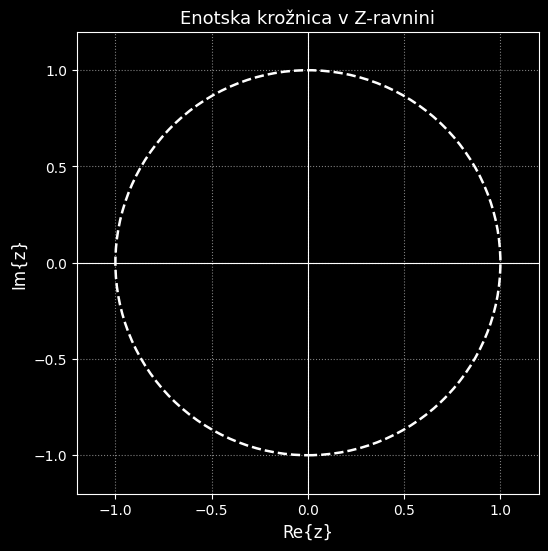

In [3]:
# Funkcija za kontrastno barvo (da je viden krog v svetli/temni temi)
from matplotlib import colors as mcolors

def _contrast_color(ax):
    r,g,b,_ = mcolors.to_rgba(ax.get_facecolor())
    lum = 0.2126*r + 0.7152*g + 0.0722*b
    return 'w' if lum < 0.5 else 'k'

fig, ax = plt.subplots()
ax.set_title('Enotska krožnica v Z-ravnini')

ec = _contrast_color(ax)
C = Circle((0,0), 1.0, fill=False, linestyle='--', edgecolor=ec, linewidth=1.8)
ax.add_patch(C)
ax.axhline(0, color=ec, lw=0.8)
ax.axvline(0, color=ec, lw=0.8)
ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
ax.set_aspect('equal', 'box')
ax.set_xlabel('Re{z}'); ax.set_ylabel('Im{z}')
ax.grid(True, ls=':', alpha=0.5)
plt.show()

## 3) Konvergenčni radij (področje konvergence) (ROC - Region Of Convergence)
Za $X(z)=\sum x[n] z^{-n}$ je **ROC** množica tistih $z$, za katere vrsta konvergira.
- Za $a^n u[n]$ je $X(z)=\frac{1}{1-a z^{-1}}$ in ROC: $|z|>|a|$.
- Za $-a^n u[-n-1]$ je ROC: $|z|<|a|$.

Če vzamemo primer geometrijske vrste: $a^n u[n]$ za $a=0.9$, je ROC: $|z|>|0.9|$.

Izračunajmo nekaj primerov vrednosti $a$ in ocenimo konvergenco vsote zaporedja.


In [4]:
# Numerična ilustracija konvergence geometrijske vrste
import numpy as np

def partial_sum_geo(a, z, N=1000):
    ratio = a/z
    if abs(ratio) < 1:
        return (1 - ratio**(N+1)) / (1 - ratio)
    else:
        return np.nan

radii = np.linspace(0.5, 1.5, 11)
vals = [partial_sum_geo(0.9, r, 500) for r in radii]
list(zip(radii, vals))

import numpy as np
import pandas as pd

# Numerična ilustracija konvergence geometrijske vrste
def partial_sum_geo(a, z, N=1000):
    ratio = a / z
    if abs(ratio) < 1:
        return (1 - ratio**(N+1)) / (1 - ratio)
    else:
        return np.nan  # označi divergentne primere

# testni radiji
radii = np.linspace(0.5, 1.5, 11)
vals = [partial_sum_geo(0.9, r, 500) for r in radii]

# ROC: |z| > |a| = 0.9
roc_flags = ["konvergira" if abs(r) > 0.9 else "divergira" for r in radii]

# Pandas tabela za lep izpis
df = pd.DataFrame({
    "z (radij)": radii,
    "partial sum (N=500)": vals,
    "ROC (|z| > 0.9)": roc_flags
})

df

,z (radij),partial sum (N=500),ROC (|z| > 0.9)
0,0.5,NaN,divergira
1,0.6,NaN,divergira
2,0.7,NaN,divergira
3,0.8,NaN,divergira
4,0.9,NaN,divergira
5,1.0,10.00,konvergira
6,1.1,5.50,konvergira
7,1.2,4.00,konvergira
8,1.3,3.25,konvergira
9,1.4,2.80,konvergira


## 4) Lastnosti Z‑transformacije
**Linearnost:**

&nbsp;&nbsp;&nbsp;$\mathcal{Z}\{a_1 x_1[n] + a_2 x_2[n]\} = a_1 X_1(z) + a_2 X_2(z)$.

&nbsp;&nbsp;&nbsp;&nbsp;ROC je presek posameznih ROC.

**Časovni premik:**

&nbsp;&nbsp;&nbsp;$\mathcal{Z}\{x[n-k]\} = z^{-k} X(z)$

&nbsp;&nbsp;&nbsp;&nbsp;ROCx razen: $z=0$ če $k>0$ ali $z=\infty$ če $k<0$.

**Konvolucija:**

&nbsp;&nbsp;&nbsp;$x[n]*h[n] \xrightarrow{\mathcal{Z}} X(z)H(z)$;

&nbsp;&nbsp;&nbsp;&nbsp;ROC je presek posameznih ROC.



Zadnja lastnost je še posebej pomembna, saj konvolucija v časovnem prostoru postane produkt v Z-prostoru.

Preverimo omenjeno lastnost na primeru množenja polinomov.

Vzemimo dve zaporedji: $x[n]=\{1,2,1\}$ in $h[n]=\{1, -0.5\}$.

Izračunajmo njuno konvolucijo  $y[n] = x[n] * h[n]$.

Sedaj izračunamo Z-transforma obeh zaporedij (dobimo polinoma spremenljivke z)

in ju pomnožimo - dobimo polinom, katerega koeficienti so enaki členom zaporedja $y[n]$.


In [5]:

# Preverimo konvolucijo na primeru
x = np.array([1, 2, 1], dtype=float)
h = np.array([1, -0.5], dtype=float)

y_time = np.convolve(x, h)  # konvolucija v času
yz_coef = np.convolve([1, 2, 1], [1, -0.5])  # produkt polinomov v z^{-1}

print("----- Vhodni signal x[n] -----")
print(x, "\n")

print("----- Enotin odziv h[n] -----")
print(h, "\n")

print("----- Izhod y[n] = x[n] * h[n] (konvolucija v času) -----")
print(y_time, "\n")

print("----- Produkt polinomov v z^{-1}: koeficienti so enaki y[n] -----")
print(yz_coef, "\n")

print("Opomba: y_time in yz_coef morata biti enaka (zamik + dolžina sta skladna).")


----- Vhodni signal x[n] -----
[1. 2. 1.] 

----- Enotin odziv h[n] -----
[ 1.  -0.5] 

----- Izhod y[n] = x[n] * h[n] (konvolucija v času) -----
[ 1.   1.5  0.  -0.5] 

----- Produkt polinomov v z^{-1}: koeficienti so enaki y[n] -----
[ 1.   1.5  0.  -0.5] 

Opomba: y_time in yz_coef morata biti enaka (zamik + dolžina sta skladna).


### Dodatna razlaga enakosti: Konvolucija koeficientov = Množenje polinomov

Naj bosta polinoma:

$$
P(x) = \sum_{k=0}^{N} a_k x^k,
\qquad
Q(x) = \sum_{m=0}^{M} b_m x^m.
$$

Njuno množenje da:

$$
R(x) = P(x) \cdot Q(x)
= \sum_{n=0}^{N+M}
\left( \sum_{k=0}^{n} a_k\, b_{n-k} \right) x^n.
$$

Koeficienti polinoma \( R(x) \) so torej:

$$
r[n] = \sum_{k=0}^{n} a_k\, b_{n-k},
$$

kar je **natanko diskretna konvolucija** zaporedij $a[n]$ in $b[n]$.

To pomeni:

- **Konvolucija** v zaporedjih **je enaka kot**
- **množenje polinomov**, ki imata te koeficiente.

Enako velja tudi za **Z‑transformacija**:

$$
X(z) = \sum_{k=0}^{N} x[k] z^{-k}, \qquad
H(z) = \sum_{m=0}^{M} h[m] z^{-m},
$$

in:

$$
Y(z) = X(z)\,H(z)
\quad\Longleftrightarrow\quad
y[n] = (x * h)[n].
$$

V spodnji Python celici je prikazan praktični primer.

In [6]:
import numpy as np
import sympy as sp
from IPython.display import display

# --- 1) Izberi koeficiente dveh polinomov (lahko spremeniš) ---
a = np.array([1, 2, 1], dtype=float)     # P(x) = 1 + 2x + x^2
b = np.array([1, -0.5], dtype=float)     # Q(x) = 1 - 0.5x

# --- 2) Množenje polinomov (algebra) === konvolucija koeficientov (signalno) ---
r_via_convolution = np.convolve(a, b)    # konvolucija koeficientov -> koef. produkta

# --- 3) Simbolni pogled s SymPy (za lep prikaz polinomov) ---
x = sp.symbols('x')
P = sum(sp.Rational(a[k]).limit_denominator() * x**k for k in range(len(a)))
Q = sum(sp.Rational(b[k]).limit_denominator() * x**k for k in range(len(b)))
R = sp.expand(P*Q)

print("----- Koeficienti polinomov -----")
print("a (P):", a)
print("b (Q):", b, "\n")

print("----- Konvolucija koeficientov (np.convolve) = koeficienti R(x) -----")
print("r =", r_via_convolution, "\n")

print("----- Simbolični polinomi -----")
display(sp.Eq(sp.Symbol('P(x)'), P))
display(sp.Eq(sp.Symbol('Q(x)'), Q))
display(sp.Eq(sp.Symbol('R(x)=P·Q'), R))

# --- 4) Kratek "unit test": ali se koeficienti ujemajo? ---
# Izvleci koeficiente R(x) v naraščajočih potencah x^0..x^n
R_poly = sp.Poly(R, x)
coeffs_R = np.array([float(R_poly.nth(k)) for k in range(R_poly.degree()+1)], dtype=float)

ok = np.allclose(coeffs_R, r_via_convolution)
print("\nPreverjanje ujemanja koeficientov:", "OK ✅" if ok else "NE USTREZA ❌")

----- Koeficienti polinomov -----
a (P): [1. 2. 1.]
b (Q): [ 1.  -0.5] 

----- Konvolucija koeficientov (np.convolve) = koeficienti R(x) -----
r = [ 1.   1.5  0.  -0.5] 

----- Simbolični polinomi -----


Eq(P(x), x**2 + 2*x + 1)

Eq(Q(x), 1 - x/2)

Eq(R(x)=P·Q, -x**3/2 + 3*x/2 + 1)


Preverjanje ujemanja koeficientov: OK ✅


## 5) Prenosna funkcija $H(z)$
Za DLČI sistem, opisan z linearnimi diferenčnimi enačbami (DE) s konstantnimi koeficienti (KK):
$$y[n] = \sum_{k=0}^{N} b_k x[n-k] - \sum_{k=1}^{M} a_k y[n-k],$$
je prevajalna (sistemska) funkcija
$$H(z) = \frac{Y(z)}{X(z)} = \frac{\sum_{k=0}^{N} b_k z^{-k}}{1 + \sum_{k=1}^{M} a_k z^{-k}}.$$

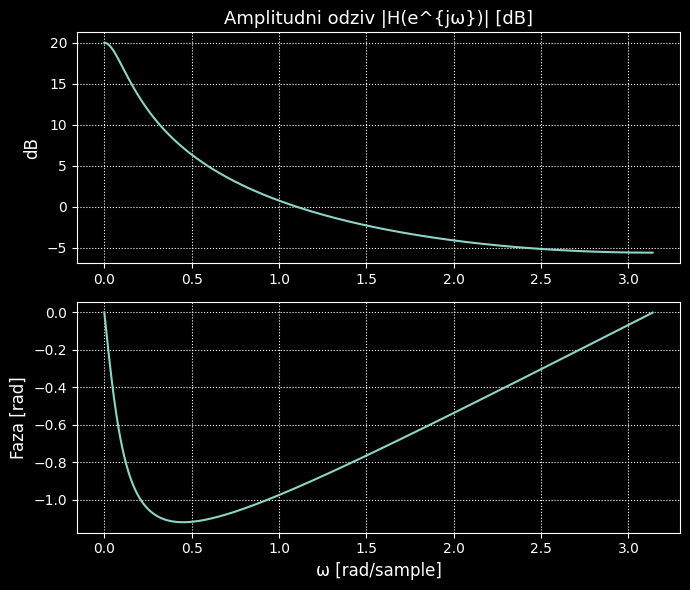

In [7]:
# Primer: H(z) = 1 / (1 - 0.9 z^{-1})
b = [1.0]
a = [1.0, -0.9]

w, H = signal.freqz(b, a, worN=1024)
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(7,6))
ax1.plot(w, 20*np.log10(np.maximum(np.abs(H),1e-12)))
ax1.set_title('Amplitudni odziv |H(e^{jω})| [dB]')
ax1.set_ylabel('dB'); ax1.grid(True, ls=':')
ax2.plot(w, np.unwrap(np.angle(H)))
ax2.set_ylabel('Faza [rad]'); ax2.set_xlabel('ω [rad/sample]'); ax2.grid(True, ls=':')
plt.tight_layout(); plt.show()

## 6) Inverzna Z‑transformacija
Za racionalne oblike uporabimo **parcialne (delne) ulomke**, tabelo $Z$-transforma ali funkcijo za simbolično računanje.

Primer izračuna inverznega $Z$-transforma: $X(z) = \dfrac{1}{1-0.5 z^{-1}} \Rightarrow x[n] = (0.5)^n u[n]$.

Enak problem najenostavneje rešimo z uporabo tabele $Z$-transformov.

In [8]:
from IPython.display import display, Math

n = sp.symbols('n', integer=True)
z = sp.symbols('z')

# your transform
X = 1/(1 - sp.Rational(1,2)*z**(-1))

# inverse Z via residue
poles = sp.solve(sp.denom(sp.simplify(X)), z)
x_raw = sum(sp.residue(X * z**(n-1), z, p) for p in poles)

# force FORMATTED result
latex_str = r"x[n] = \left(\frac{1}{2}\right)^n\,u[n]"

display(Math(latex_str))


<IPython.core.display.Math object>

## 7) Racionalni Z‑transformi, poli in ničle
Vsi DLČI sistemi, opisljivi z diferenčnimi enačbami s konstantnimi koeficienti imajo racionalne $Z$-transforme:

$$H(z)=\dfrac{\sum_{k=0}^{N} b_k z^{-k}}{1+\sum_{k=1}^{M} a_k z^{-k}}$$ kjer so **ničle** ničle števca, **poli** pa ničle imenovalca.

Množica polov in ničel prevajalne funkcije določa dinamiko, stabilnost ter tudi potek frekvenčnega odziva.

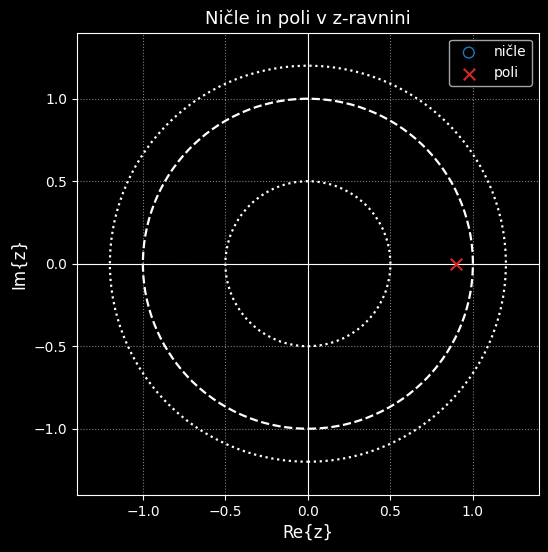

In [9]:
# Izris ničel in polov + enotska krožnica

def plot_zplane(b, a, radii=(1.0,), ax=None, title='Ničle in poli v z-ravnini'):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,6))
    z, p, k = signal.tf2zpk(b, a)
    # kontrastna barva robov
    r,g,bg,_ = mcolors.to_rgba(ax.get_facecolor())
    ec = 'w' if (0.2126*r + 0.7152*g + 0.0722*bg) < 0.5 else 'k'
    for r0 in radii:
        ax.add_patch(Circle((0,0), r0, fill=False, ls='--' if r0==1.0 else ':', edgecolor=ec, lw=1.6))
    ax.scatter(z.real, z.imag, marker='o', s=60, facecolors='none', edgecolors='tab:blue', label='ničle', zorder=3)
    ax.scatter(p.real, p.imag, marker='x', s=70, color='tab:red', label='poli', zorder=4)
    ax.axhline(0, color=ec, lw=0.8)
    ax.axvline(0, color=ec, lw=0.8)
    ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4)
    ax.set_aspect('equal', 'box')
    ax.set_xlabel('Re{z}'); ax.set_ylabel('Im{z}')
    ax.grid(True, ls=':', alpha=0.5)
    ax.set_title(title)
    ax.legend(loc='upper right')
    return ax

b = [1.0]
a = [1.0, -0.9]
plot_zplane(b, a, radii=(1.0, 0.5, 1.2))
plt.show()

## 8) Stabilnost
Kavzalni LČI sistem je **stabilen n.t.k.** so vsi poli **znotraj** enotske krožnice ($|p_i|<1$).

In [10]:
def is_stable(a):
    p = np.roots(a)
    return np.all(np.abs(p) < 1), p

cases = {
    'stabilen': [1.0, -0.6],
    'mejni': [1.0, -1.0],
    'nestabilen': [1.0, -1.2]
}
for name, aa in cases.items():
    ok, p = is_stable(aa)
    print(f"{name}: poli={p}, stabilnost={ok}")

stabilen: poli=[0.6], stabilnost=True
mejni: poli=[1.], stabilnost=False
nestabilen: poli=[1.2], stabilnost=False


## 9) Realizacijske strukture (DF1, DF2, kaskadna, paralelna)
**DF1/DF2:** neposredni obliki, izpeljani iz DE. DF2 minimizira število pomnilniških celic.

**Kaskadna/paralelna:** faktorizacija v ničle/pole ali parcialne ulomke - enostavnejše podsisteme, nato povezovanje v zaporedne in/ali vzporedne vezave.

# TF vs. SOS po kvantizaciji koeficientov — razlaga, formule, DF/SOS realizacije

Spodaj je razlaga z enačbami in strukturo realizacij za celico, ki primerja **polinomsko TF** (TF=Transfer Function - prevajalna funkcija) in **SOS** predstavo filtra po **kvantizaciji koeficientov** (sliderji: `order`, `fc`, `ripple`, `frac`, `dc_balance`, …). V kodi generiraš Butterworth/Chebyshev‑ filter, kvantiziraš TF/SOS koeficiente in primerjaš spektralne odzive (`freqz`, `sosfreqz`), vključno z *passband zoom* in *error plots*.

---

## 1) Prenosna funkcija, spektralni odziv in kvantizacija

Za IIR nizkoprepustni filter (Butterworth ali Chebyshev I) je **prenosna funkcija** v $z$‑domeni:

$$
H(z) \;=\; \frac{Y(z)}{X(z)}
\;=\;
\frac{\displaystyle \sum_{k=0}^{N} b_k\,z^{-k}}{\displaystyle 1+\sum_{k=1}^{N} a_k\,z^{-k}}\,.
$$

V celici generiraš $(b,a)$ preko `signal.butter` ali `signal.cheby1`, nato pretvoriš v **SOS** z `signal.tf2sos`. Spektralni odziv iz TF/SOS izračunaš z `signal.freqz(b,a)` in `signal.sosfreqz(SOS)`, amplitude prikazuješ v dB $\big(20\log_{10}\lvert H(e^{j\omega})\rvert\big)$, dodatno pa narišeš še v linearnem merilu in graf z **napako** $\Delta(\omega)=20\log_{10}|H_Q|-20\log_{10}|H|$.

### 1.1 Kvantizacija koeficientov (fractional bits)

Kvantiziraš s funkcijo:

$$
\widetilde{x} \;=\; \operatorname{round}\!\left(\frac{x}{2^{-F}}\right)\,2^{-F}
\quad\text{(z `frac = F` fractional bits),}
$$

in to uporabiš za TF polinoma $(b,a)$ ter posebej za SOS koeficiente (stolpci `:3` in `4:6` v matriki SOS). Po kvantizaciji izrišeš $H_{\text{TF}Q}$ in $H_{\text{SOS}Q}$ ter ju primerjaš z idealnim $H$.

---

## 2) Direktne (DF) realizacije polinomske TF

Če bi TF realiziral neposredno s polinomi $(b,a)$, sta najpogostejši **DF1** in **DF2/DF2T** (tu celica sicer analizira frekvenčno, ne časovno, a razumevanje struktur pomaga pri interpretaciji napak). Za IIR velja:

$$
y[n]\;=\;\sum_{k=0}^{N} b_k\,x[n-k]\;-\;\sum_{k=1}^{N} a_k\,y[n-k]\,.
$$

### 2.1 DF1 (Direct Form I)

- **Vhodni del (FIR):** $v[n] = \sum_{k=0}^{N} b_k\,x[n-k]$
- **Povratni del (IIR):** $y[n] = v[n] - \sum_{k=1}^{N} a_k\,y[n-k]$

Problem pri **koeficientni kvantizaciji polinoma**: koeficienti višjih stopenj so pogosto najbolj izpostavljeni; že majhne napake se **globalno** projicirajo čez cel spekter in povzročijo vidna odstopanja (to v celici vidiš kot večjo napako »TF quant error«).


### 2.2 DF2 / DF2T (Direct Form II / Transposed)

**DF2T** ima boljšo numerično robustnost (manj stanj, ugodno round‑off vedenje), vendar ostane osnovna težava **globalne** polinomske kvantizacije: napake v koeficientih $(b,a)$ vplivajo na **celoten** $H(z)$. To pojasni, zakaj $H_{\text{TF}Q}$ praviloma odstopa bolj kot $H_{\text{SOS}Q}$ pri istem `frac`.

---

## 3) SOS: kaskada sekcij 2. reda

Namesto enega polinoma faktoriraš $H(z)$ v produkt **sekcij 2. reda**:

$$
H(z) \;=\; \prod_{i=1}^{S} H_i(z),
\qquad
H_i(z)=\frac{b_{i,0}+b_{i,1}z^{-1}+b_{i,2}z^{-2}}
{1+a_{i,1}z^{-1}+a_{i,2}z^{-2}},
\quad S=\frac{N}{2}\,.
$$

**Kvantiziraš koeficiente vsake sekcije posebej** in sekcije (v praksi DF2T) realiziraš v kaskadi. Prednosti:

- **Lokalnost:** napaka v eni sekciji ostane lokalizirana → *manjša globalna napaka*.
- **Boljša stabilnost koeficientov** 2. reda.
- **Numerična robustnost** pri višjih redih in ožjih prehodnih pasovih.

Zato v grafih skoraj vedno opaziš, da je **»SOS quant error«** občutno manjši kot **»TF quant error«** pri istem `frac`.

---

## 4) DC‑balansiranje SOS (helper `sos_balance_dc`)

V celici normaliziraš **DC ojačenje** vsake SOS sekcije in se izogneš sekcijam z (skoraj) ničelnim numeratorjem, ki bi bile po kvantizaciji izjemno občutljive. Ideja:

$$
G_i \;=\; \frac{b_{i,0}+b_{i,1}+b_{i,2}}{1+a_{i,1}+a_{i,2}},
\qquad
(b_{i,0},b_{i,1},b_{i,2}) \leftarrow \frac{1}{G_i}\,(b_{i,0},b_{i,1},b_{i,2}),
$$

in na **zadnji** sekciji kompenziraš, da ohraniš globalni DC gain. Tako **ne spremeniš** globalnega $H(z)$, le razporeditev ojačanja po sekcijah je stabilnejša za kvantizacijo.

---

## 5) DF2T enačbe za eno SOS sekcijo (za časovno realizacijo)

Če želiš časovno realizirati 2. red (npr. s fiksno vejico):

$$
\begin{aligned}
y[n] &= b_{0}\,x[n] + w_{1}[n-1],\\\\
w_{1}[n] &= b_{1}\,x[n] - a_{1}\,y[n] + w_{2}[n-1],\\\\
w_{2}[n] &= b_{2}\,x[n] - a_{2}\,y[n].
\end{aligned}
$$

Stanja $(w_1,w_2)$ kvantiziraš/saturiraš po potrebi. Kaskada SOS = zaporedni klic teh enačb za vse sekcije. Za polinomsko TF ta »lokalna« prednost odpade — še vedno je problem zaradi globalne kvantizacije koeficientov).

---

## 6) Kaj v grafih tipično vidiš (in zakaj)

- Pri večjem `order` in manjšem `frac` se TF (polinom) **hitreje degradira**: opazna odstopanja v passbandu in večja **Error vs. ideal (dB)**.
- SOS ostaja **blizu ideala** zaradi lokalizacije napake; z `dc_balance=True` še dodatno stabiliziraš numeratorje.
- Chebyshev I (zaradi valovanja v passbandu) še poudari razliko — TF je po kvantizaciji še bolj občutljiv, SOS manj.

---

## 7) Praktični namigi za tvojo celico

- Za »učbenik« razlik: `order` ≥ 10 in `frac` ~ 7–8 → TF napaka opazno večja od SOS.
- Zoži **Error** os na ±0.5 dB, ko želiš fino razlikovanje.
- Pusti `dc_balance=True`, da se izogneš SOS sekcijam z skoraj ničelnim DC‑numeratorjem.

---

## 8) Povzetek DF vs. SOS (po kvantizaciji koeficientov)

- **TF/DF1–DF2T (polinomsko):** globalna kvantizacija → napaka se »razlije« po celotnem spektru; pri višjih redih je napaka večja.
- **SOS (kaskada 2. reda):** lokalna kvantizacija → napaka ostane lokalna; koeficienti so bolje pogojeni; z `sos_balance_dc` še stabilnejše → **občutno manjša napaka**.
- Tvoja primerjava $H_{\text{TF}Q}$ vs $H_{\text{SOS}Q}$ (magnitude, passband‑zoom, error‑plot) to jasno pokaže.


In [12]:
#import numpy as np
#import scipy.signal as signal
#import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown, Checkbox

def dB(x, floor=1e-15):
    return 20*np.log10(np.maximum(np.abs(x), floor))

def quantize_frac(x, nfrac):
    step = 2.0**(-nfrac)
    return np.round(np.asarray(x)/step)*step

def sos_balance_dc(sos):
    # uravnoteži DC-gain vsake SOS sekcije, da numeratorji ne postanejo ~0 po kvantizaciji
    sos = sos.copy().astype(float)
    def dc_gain(sec):
        b0,b1,b2,a0,a1,a2 = sec
        return (b0+b1+b2)/(a0+a1+a2)
    G0 = np.prod([dc_gain(sec) for sec in sos])
    for i in range(sos.shape[0]):
        g = dc_gain(sos[i]);  g = 1.0 if abs(g) < 1e-18 else g
        sos[i,0:3] /= g
    G1 = np.prod([dc_gain(sec) for sec in sos])
    if abs(G1) > 1e-18:
        sos[-1,0:3] *= (G0/G1)
    return sos

@interact(
    ftype=Dropdown(options=['Butterworth','Chebyshev I'], value='Butterworth', description='Tip'),
    order=IntSlider(min=4, max=12, step=2, value=8, description='Order'),
    fc=FloatSlider(min=0.05, max=0.45, step=0.05, value=0.20, description='fc (rel)'),
    ripple=FloatSlider(min=0.1, max=1.0, step=0.1, value=0.5, readout_format='.1f', description='Ripple[dB]'),
    frac=IntSlider(min=6, max=14, step=1, value=10, description='Frac bits'),
    pass_lo=FloatSlider(min=0.0, max=0.999, step=0.01, value=0.0, readout_format='.3f', description='|H|min'),
    pass_hi=FloatSlider(min=1.0, max=1.5, step=0.1, value=1.2, readout_format='.3f', description='|H|max'),
    dc_balance=Checkbox(value=True, description='DC balance SOS')
)
def tf_vs_sos(ftype, order, fc, ripple, frac, pass_lo, pass_hi, dc_balance):
    # 1) filter (TF + SOS)
    if ftype == 'Butterworth':
        b, a = signal.butter(order, fc)
    else:
        b, a = signal.cheby1(order, ripple, fc)
    sos = signal.tf2sos(b, a)
    if dc_balance:
        sos = sos_balance_dc(sos)

    # 2) koeficientna kvantizacija (TF polinomi in SOS sekcije)
    bq, aq = quantize_frac(b, frac), quantize_frac(a, frac)
    sosq   = sos.copy()
    sosq[:, :3]  = quantize_frac(sosq[:, :3],  frac)
    sosq[:, 4:6] = quantize_frac(sosq[:, 4:6], frac)

    # 3) frekvenčni odzivi (brez časovne simulacije -> brez overflow)
    w,  H_id   = signal.freqz(b, a, worN=4096)
    _,  H_tfQ  = signal.freqz(bq, aq, worN=4096)
    _,  H_sosQ = signal.sosfreqz(sosq, worN=4096)

    # --- (a) Magnitude dB
    plt.figure(figsize=(10,5))
    plt.plot(w, dB(H_id),   lw=2, label='Ideal (TF)')
    plt.plot(w, dB(H_tfQ), '--', label=f'TF quant ({frac}b frac)')
    plt.plot(w, dB(H_sosQ),'--', label=f'SOS quant ({frac}b frac)')
    plt.title(f"{ftype} LPF (order {order}) — Coefficient quantization")
    plt.xlabel("ω [rad/sample]"); plt.ylabel("Magnitude [dB]")
    plt.ylim(-200, 3); plt.grid(True, ls=':'); plt.legend(); plt.tight_layout(); plt.show()

    # --- (b) Passband zoom (linear) – omogoči, da je SOS "viden"
    plt.figure(figsize=(10,4))
    plt.plot(w, np.abs(H_id),   lw=2, label='Ideal')
    plt.plot(w, np.abs(H_tfQ), '--', label='TF quant')
    plt.plot(w, np.abs(H_sosQ),'--', label='SOS quant')
    plt.title("Passband (linear) — zoom")
    plt.xlabel("ω [rad/sample]"); plt.ylabel("|H|")
    plt.xlim(0, 0.8*np.pi); plt.ylim(pass_lo, pass_hi)
    plt.grid(True, ls=':'); plt.legend(); plt.tight_layout(); plt.show()

    # --- (c) Error vs. ideal (dB) – ozka skala
    err_tf  = dB(H_tfQ)  - dB(H_id)
    err_sos = dB(H_sosQ) - dB(H_id)
    plt.figure(figsize=(10,4))
    plt.plot(w, err_tf,  '--', label='TF quant error')
    plt.plot(w, err_sos,'--', label='SOS quant error')
    plt.title("Error vs. ideal (dB) — zoom")
    plt.xlabel("ω [rad/sample]"); plt.ylabel("Δ [dB]")
    plt.xlim(0, 0.8*np.pi); plt.ylim(-20, 20)
    plt.grid(True, ls=':'); plt.legend(); plt.tight_layout(); plt.show()


interactive(children=(Dropdown(description='Tip', options=('Butterworth', 'Chebyshev I'), value='Butterworth')…

#### Povzetek opažanj

- **DF1/DF2**: Kvantizacija koeficientov in stanj povzroči premike polov in opazno izkrivljanje impulznega/frekvenčnega odziva. Pri polih blizu enotske krožnice lahko pride do velikih odstopanj ali celo nestabilnosti.

- **Kaskadna (SOS)**: Razbitje v sekcije 2. reda lokalizira napake kvantizacije. Odziv ostane bistveno bližje idealnemu. Zato je SOS v praksi standardna izbira za IIR v omejeni natančnosti.

- **Kvantizacija stanj** je prav tako pomembna kot kvantizacija koeficientov — DF1/DF2 sta pri tem bolj občutljiva od SOS.

---

## Vaje (teorija + kratki izračuni)
1. Določite $X(z)$ za $x[n]=\delta[n]+2\delta[n-1]+\delta[n-2]$ in opišite ROC.
2. Za $x[n]=0.8^n u[n]$ določite ROC; kdaj obstaja DTFT?
3. Podan je sistem $H(z)=\dfrac{1}{1-1.2z^{-1}+0.36z^{-2}}$. Določite pole in stabilnost.
4. Izvedite parcialne ulomke za $X(z)=\dfrac{z^{-1}+2z^{-2}}{1-0.6z^{-1}}$ in izračunajte $x[n]$.